In [1]:
! pip install openpyxl seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_ZugA = pd.read_excel('Statistiken-zur-VL-STAT-WS1718-angepasst-02.xlsx', sheet_name='Urlisten', skiprows=23, nrows=4, header=0, usecols="A:AQ")
df_ZugB = pd.read_excel('Statistiken-zur-VL-STAT-WS1718-angepasst-02.xlsx', sheet_name='Urlisten', skiprows=30, nrows=4, header=1, usecols="A:AE")

In [4]:
def prepare_df(df):
    df = df.drop(columns="wi")
    cols = df["Element#"].values
    df = df.T
    df.reset_index(inplace=True, drop=True)
    df.columns = cols
    df = df.iloc[1:]
    df["Alter"] = df["Alter"].astype(int)
    df.rename(columns={"Köperlänge": "Körperlänge"}, inplace=True)
    df["Körperlänge"] = df["Körperlänge"].astype(int)
    return df

In [5]:
df_ZugA = prepare_df(df_ZugA)
df_ZugB = prepare_df(df_ZugB)
df = pd.concat([df_ZugA, df_ZugB], ignore_index=True)

In [6]:
df

,Alter,Körperlänge,Berufsausb.,Geschlecht
0,22,187,n,m
1,21,178,n,m
2,23,170,n,m
3,24,170,n,m
4,24,171,n,m
...,...,...,...,...
65,21,174,n,w
66,25,176,j,w
67,25,170,n,m
68,22,165,n,w


In [7]:
df.describe()

,Alter,Körperlänge
count,70.000000,70.000000
mean,22.657143,176.071429
std,2.238567,9.546714
min,19.000000,155.000000
25%,21.000000,170.000000
50%,22.000000,176.000000
75%,24.000000,183.750000
max,28.000000,195.000000


In [8]:
df.describe(include="all")

,Alter,Körperlänge,Berufsausb.,Geschlecht
count,70.000000,70.000000,70,70
unique,NaN,NaN,2,2
top,NaN,NaN,n,m
freq,NaN,NaN,53,47
mean,22.657143,176.071429,NaN,NaN
std,2.238567,9.546714,NaN,NaN
min,19.000000,155.000000,NaN,NaN
25%,21.000000,170.000000,NaN,NaN
50%,22.000000,176.000000,NaN,NaN
75%,24.000000,183.750000,NaN,NaN


In [9]:
df["Alter"].min()

np.int64(19)

In [10]:
df["Alter"].max()

np.int64(28)

pandas histogram plot

<Axes: ylabel='Frequency'>

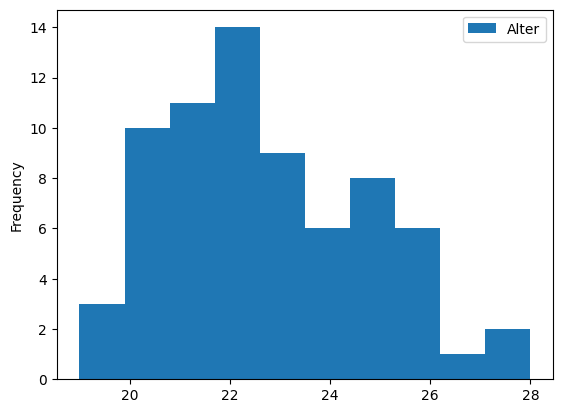

In [11]:
df.plot.hist(column="Alter", bins=10)

<Axes: >

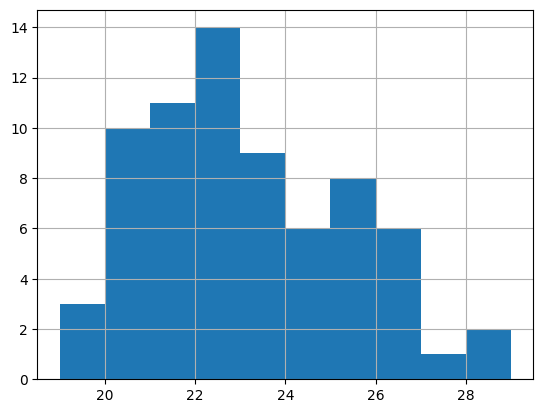

In [12]:
bin_width = 1
bins_alter = np.arange(df["Alter"].min(), df["Alter"].max()+1 + bin_width, bin_width)
df["Alter"].hist(bins=bins_alter)

<Axes: ylabel='Density'>

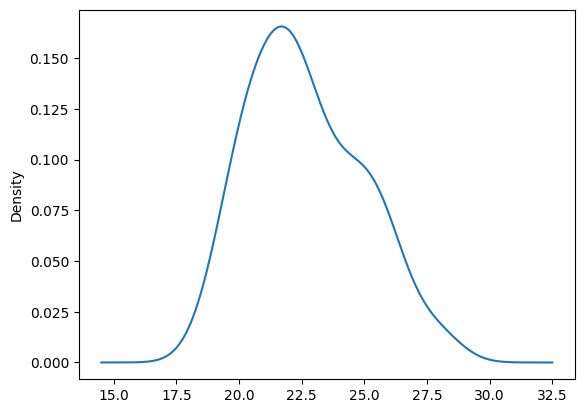

In [13]:
df["Alter"].plot(kind="kde")

<Axes: >

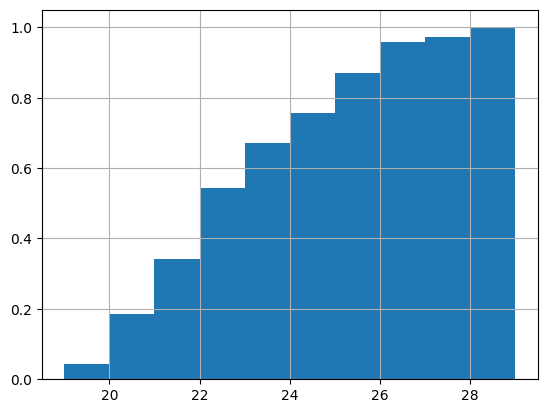

In [14]:
df["Alter"].hist(cumulative=True, density=True, bins=bins_alter)

<Axes: >

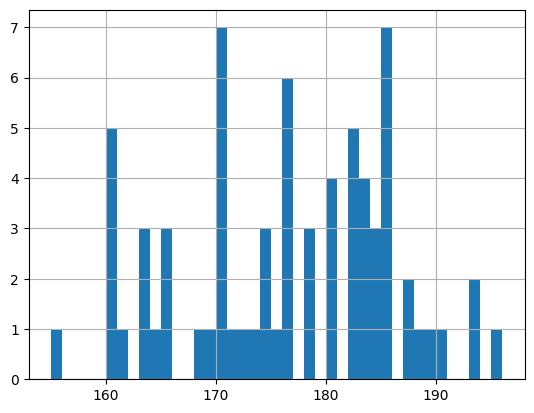

In [15]:
bin_width = 1
bins_körperlänge = np.arange(df["Körperlänge"].min(), df["Körperlänge"].max()+1 + bin_width, bin_width)
df["Körperlänge"].hist(bins=bins_körperlänge)

<Axes: >

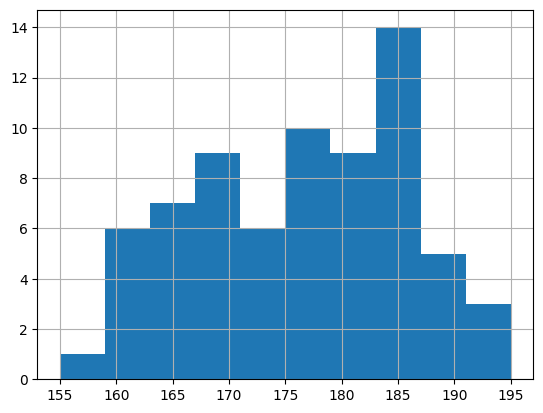

In [16]:
df["Körperlänge"].hist(bins=10)

<Axes: ylabel='Density'>

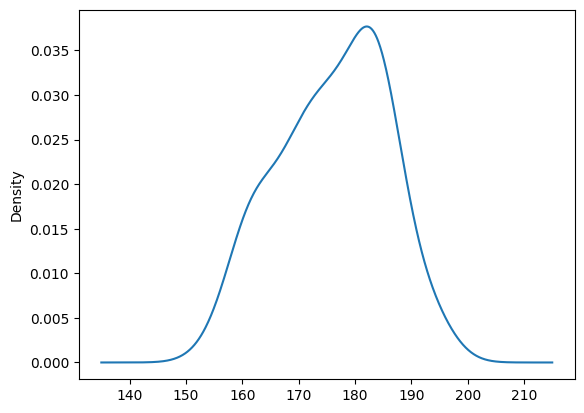

In [17]:
df["Körperlänge"].plot(kind="kde")

<Axes: >

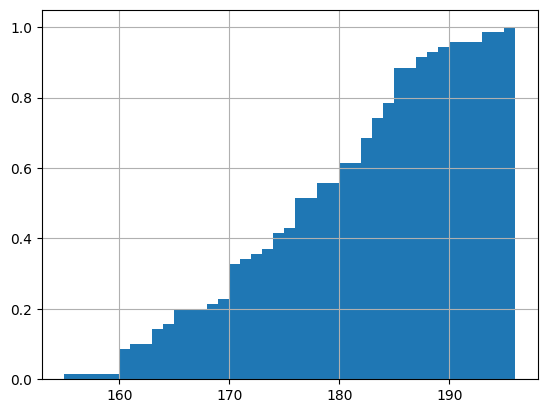

In [18]:
df["Körperlänge"].hist(cumulative=True, density=True, bins=bins_körperlänge)

Alternative: matplotlib histogram

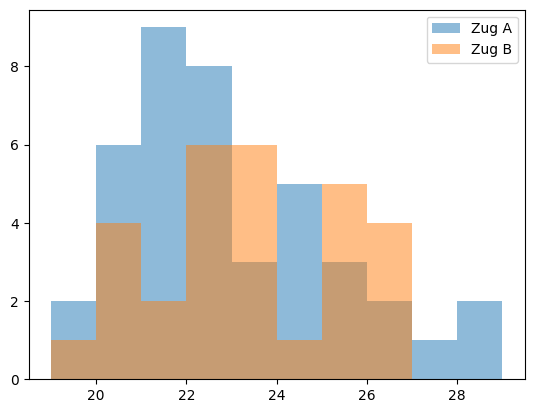

In [19]:
plt.hist(df_ZugA["Alter"], bins=bins_alter, alpha=0.5)
plt.hist(df_ZugB["Alter"], bins=bins_alter, alpha=0.5)
plt.legend(["Zug A", "Zug B"])

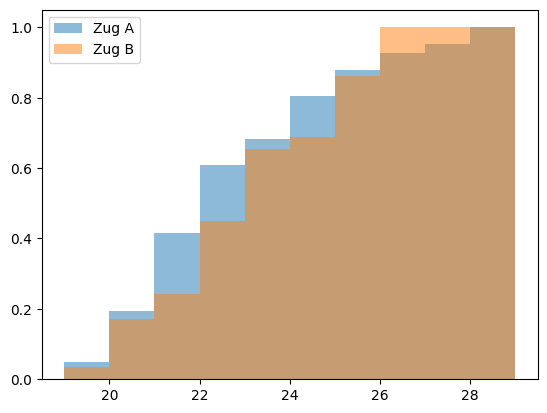

In [20]:
plt.hist(df_ZugA["Alter"], cumulative=True, density=True, bins=bins_alter, alpha=0.5)
plt.hist(df_ZugB["Alter"], cumulative=True, density=True, bins=bins_alter, alpha=0.5)
plt.legend(["Zug A", "Zug B"])

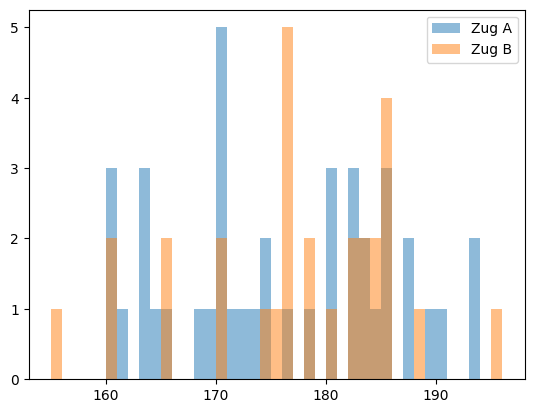

In [21]:
plt.hist(df_ZugA["Körperlänge"], bins=bins_körperlänge, alpha=0.5)
plt.hist(df_ZugB["Körperlänge"], bins=bins_körperlänge, alpha=0.5)
plt.legend(["Zug A", "Zug B"])

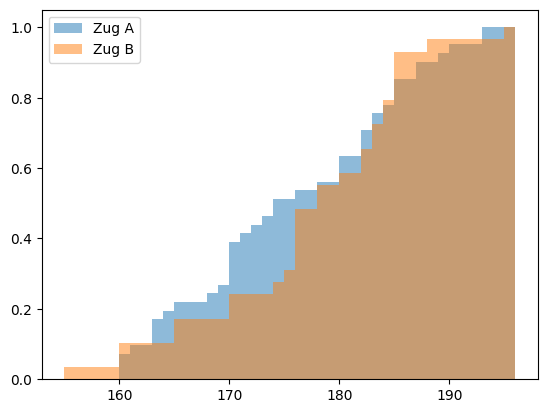

In [22]:
plt.hist(df_ZugA["Körperlänge"], cumulative=True, density=True, bins=bins_körperlänge, alpha=0.5)
plt.hist(df_ZugB["Körperlänge"], cumulative=True, density=True, bins=bins_körperlänge, alpha=0.5)
plt.legend(["Zug A", "Zug B"])

vertical bar chart for string columns

<Axes: xlabel='Geschlecht'>

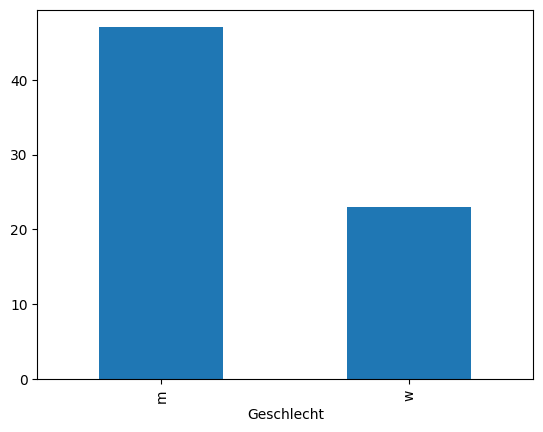

In [23]:
df["Geschlecht"].value_counts().plot(kind="bar")

<Axes: xlabel='Berufsausb.'>

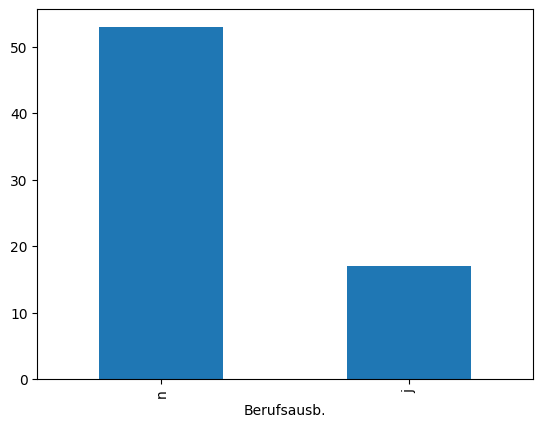

In [24]:
df["Berufsausb."].value_counts().plot(kind="bar")

<Axes: title={'center': 'Körperlänge'}, xlabel='Geschlecht'>

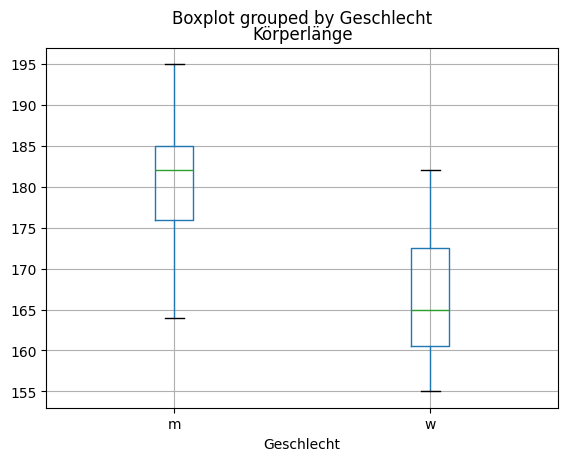

In [25]:
df.boxplot(column="Körperlänge", by="Geschlecht")

<Axes: xlabel='Alter', ylabel='Körperlänge'>

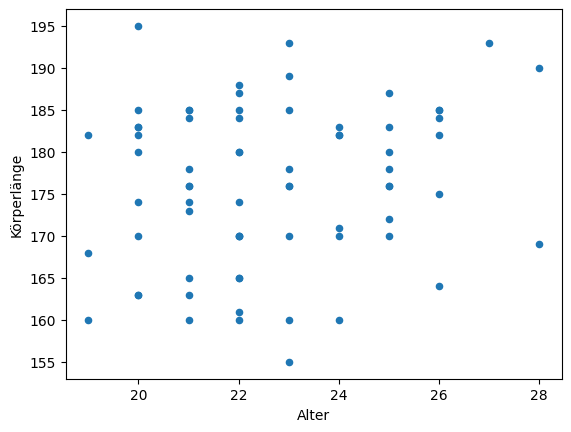

In [26]:
df.plot.scatter(x="Alter", y="Körperlänge")

array([[<Axes: xlabel='Alter', ylabel='Alter'>,
        <Axes: xlabel='Körperlänge', ylabel='Alter'>],
       [<Axes: xlabel='Alter', ylabel='Körperlänge'>,
        <Axes: xlabel='Körperlänge', ylabel='Körperlänge'>]], dtype=object)

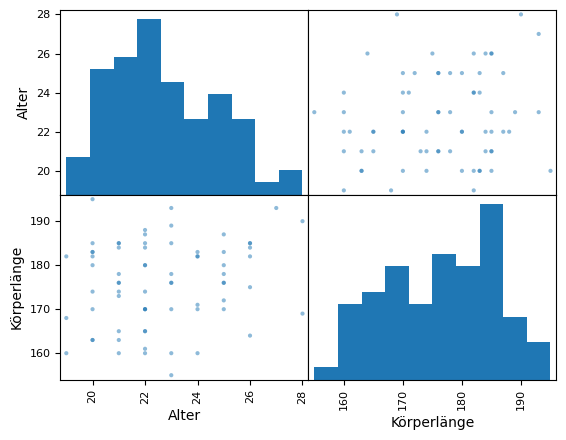

In [27]:
pd.plotting.scatter_matrix(df)

In [28]:
df[["Alter", "Körperlänge"]].corr()

,Alter,Körperlänge
Alter,1.000000,0.175448
Körperlänge,0.175448,1.000000


<Axes: >

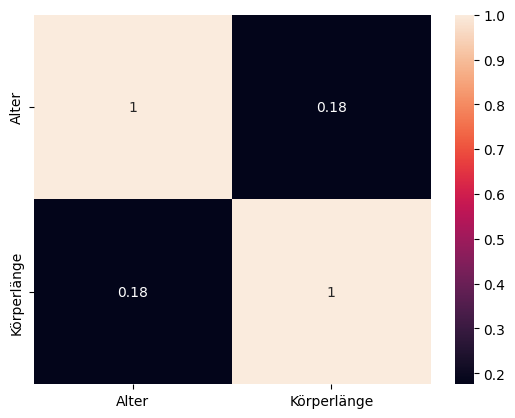

In [29]:
sns.heatmap(df[["Alter", "Körperlänge"]].corr(), annot=True)